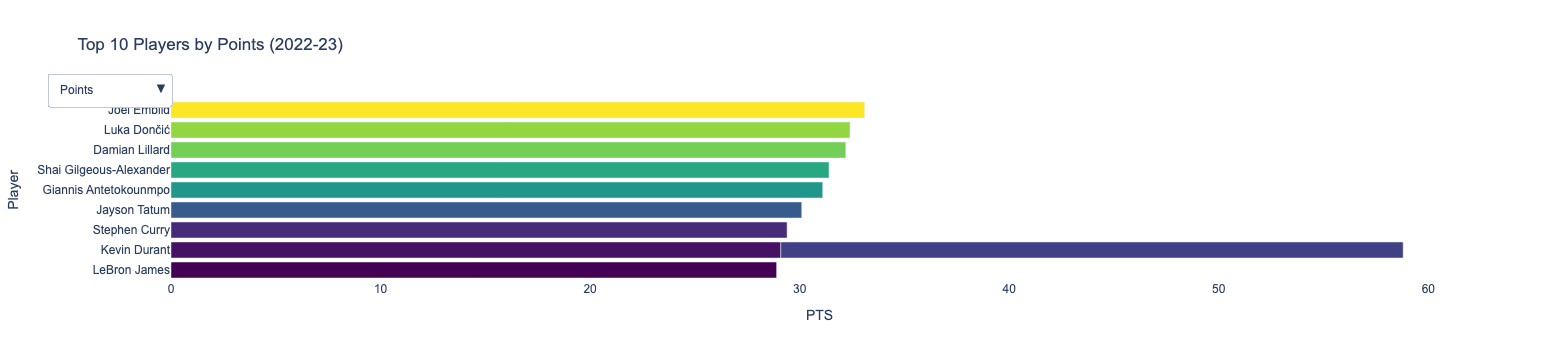

In [83]:
# Top 10 Player Stats for 2022-2023 NBA Season
import pandas as pd
import plotly.express as px
from ipywidgets import interact, widgets

# Load data
url = "https://www.basketball-reference.com/leagues/NBA_2023_per_game.html"
tables = pd.read_html(url)
player_stats = tables[0]

# Clean
player_stats = player_stats[player_stats['Rk'] != 'Rk']
stat_cols = ['PTS', 'AST', 'TRB', 'STL', 'BLK']
player_stats[stat_cols] = player_stats[stat_cols].apply(pd.to_numeric)

# Build one figure with a dropdown button
stat_labels = ['Points', 'Assists', 'Total Rebounds', 'Steals', 'Blocks']
stat_cols_map = ['PTS', 'AST', 'TRB', 'STL', 'BLK']

# Start with PTS
top10 = player_stats.nlargest(10, 'PTS').iloc[::-1]

fig = px.bar(top10, x='PTS', y='Player', orientation='h',
             title='Top 10 Players by Points (2022-23)',
             color='PTS', color_continuous_scale='viridis')

# Build dropdown buttons
buttons = []
for label, stat in zip(stat_labels, stat_cols_map):
    top10 = player_stats.nlargest(10, stat).iloc[::-1]
    buttons.append(dict(
        label=label,
        method='update',
        args=[
            {'x': [top10[stat]], 'y': [top10['Player']]},
            {'title': f'Top 10 Players by {label} (2022-23)',
             'xaxis.title': label}
        ]
    ))

fig.update_layout(
    updatemenus=[dict(buttons=buttons, direction='down', x=0, y=1.15)],
    coloraxis_showscale=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font_family='Arial'
)

fig.show()

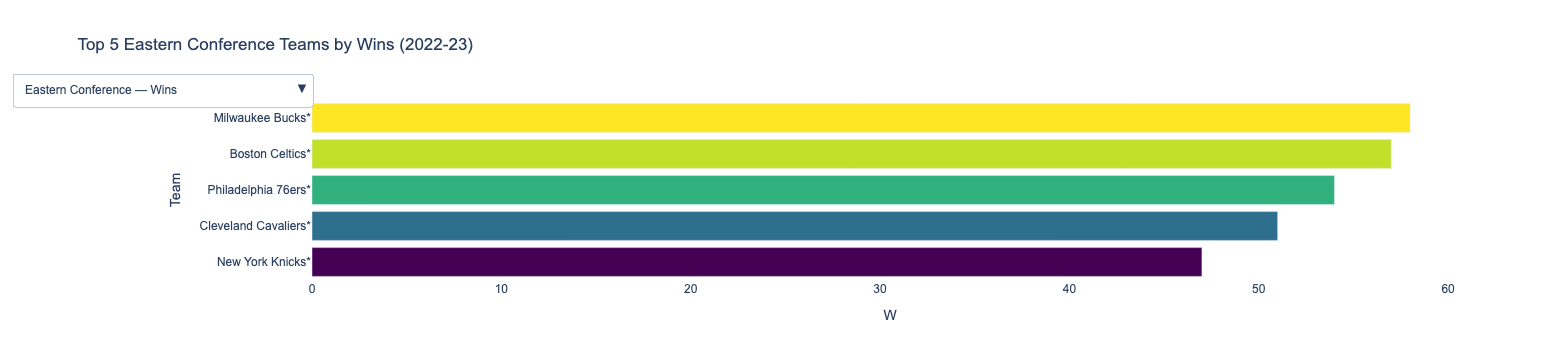

In [84]:
# Top 5 Teams by Conference
import pandas as pd
import plotly.express as px

url_standings = "https://www.basketball-reference.com/leagues/NBA_2023_standings.html"
tables_standings = pd.read_html(url_standings)

east = tables_standings[0].rename(columns={'Eastern Conference': 'Team'})
west = tables_standings[1].rename(columns={'Western Conference': 'Team'})

stat_cols = ['W', 'L', 'W/L%', 'PS/G']
east[stat_cols] = east[stat_cols].apply(pd.to_numeric, errors='coerce')
west[stat_cols] = west[stat_cols].apply(pd.to_numeric, errors='coerce')

# Start with East, Wins
top5 = east.nlargest(5, 'W').iloc[::-1]

fig = px.bar(top5, x='W', y='Team', orientation='h',
             title='Top 5 Eastern Conference Teams by Wins (2022-23)',
             color='W', color_continuous_scale='viridis')

# Build all combinations of conference + stat buttons
stat_labels = ['Wins', 'Losses', 'Win %', 'Points Scored per Game']
stat_keys   = ['W',    'L',      'W/L%',  'PS/G']
conferences = {'Eastern Conference': east, 'Western Conference': west}

buttons = []
for conf_label, df in conferences.items():
    for stat_label, stat in zip(stat_labels, stat_keys):
        top5 = df.nlargest(5, stat).iloc[::-1]
        buttons.append(dict(
            label=f'{conf_label} — {stat_label}',
            method='update',
            args=[
                {'x': [top5[stat]], 'y': [top5['Team']]},
                {'title': f'Top 5 {conf_label} Teams by {stat_label} (2022-23)',
                 'xaxis.title': stat_label}
            ]
        ))

fig.update_layout(
    updatemenus=[dict(buttons=buttons, direction='down', x=0, y=1.15)],
    coloraxis_showscale=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font_family='Arial'
)

fig.show()

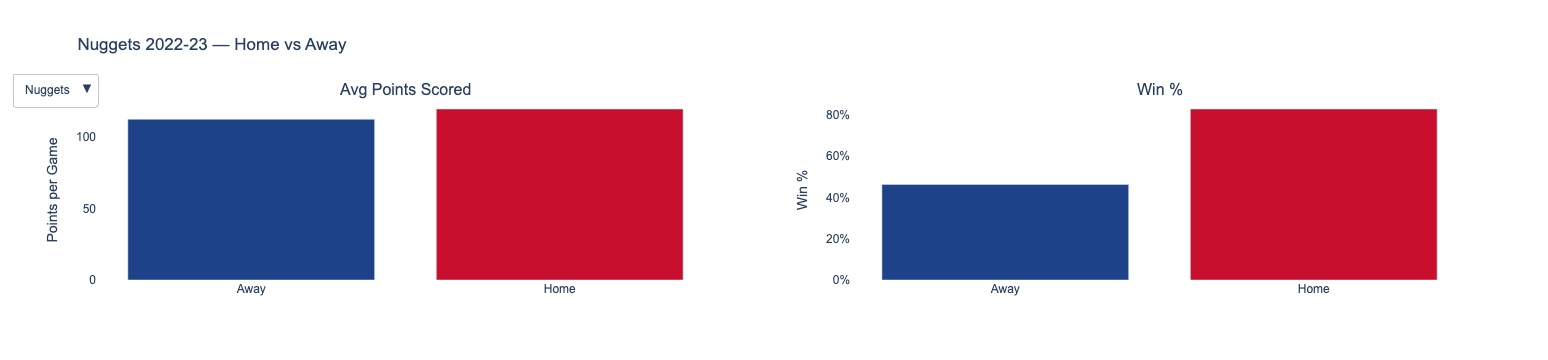

In [85]:
# Finalist Home vs Away Team Stats
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.ticker as mtick

def load_gamelog(url):
    df = pd.read_html(url)[0]
    df.columns = ['_'.join(col).strip() for col in df.columns]
    df = df.rename(columns={
        'Unnamed: 0_level_0_Rk': 'Rk',
        'Unnamed: 2_level_0_Date': 'Date',
        'Unnamed: 3_level_0_Unnamed: 3_level_1': 'HomeAway',
        'Unnamed: 4_level_0_Opp': 'Opp',
        'Score_Rslt': 'Result',
        'Score_Tm': 'PTS',
        'Score_Opp': 'PTS_Opp'
    })
    df = df[pd.to_numeric(df['Rk'], errors='coerce').notna()]
    df['PTS'] = pd.to_numeric(df['PTS'])
    df['PTS_Opp'] = pd.to_numeric(df['PTS_Opp'])
    df['Location'] = df['HomeAway'].apply(lambda x: 'Away' if x == '@' else 'Home')
    df['Win'] = df['Result'].apply(lambda x: 1 if x == 'W' else 0)
    return df

nuggets = load_gamelog("https://www.basketball-reference.com/teams/DEN/2023/gamelog")
heat = load_gamelog("https://www.basketball-reference.com/teams/MIA/2023/gamelog")
teams = {'Nuggets': nuggets, 'Heat': heat}

def make_home_away_fig(team_name):
    df = teams[team_name]
    summary = df.groupby('Location').agg(
        Avg_PTS=('PTS', 'mean'),
        Win_Pct=('Win', 'mean')
    ).reset_index()

    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=('Avg Points Scored', 'Win %'))

    colors = ['#1d428a', '#c8102e']

    fig.add_trace(go.Bar(
        x=summary['Location'], y=summary['Avg_PTS'],
        marker_color=colors, showlegend=False
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=summary['Location'], y=summary['Win_Pct'],
        marker_color=colors, showlegend=False
    ), row=1, col=2)

    fig.update_yaxes(title_text='Points per Game', row=1, col=1)
    fig.update_yaxes(title_text='Win %', tickformat='.0%', row=1, col=2)
    fig.update_layout(
        title=f'{team_name} 2022-23 — Home vs Away',
        paper_bgcolor='white',
        plot_bgcolor='white',
        font_family='Arial'
    )
    return fig

# Dropdown using plotly buttons
fig = make_home_away_fig('Nuggets')

nuggets_summary = nuggets.groupby('Location').agg(Avg_PTS=('PTS','mean'), Win_Pct=('Win','mean')).reset_index()
heat_summary = heat.groupby('Location').agg(Avg_PTS=('PTS','mean'), Win_Pct=('Win','mean')).reset_index()

buttons = [
    dict(label='Nuggets', method='update',
         args=[{'y': [nuggets_summary['Avg_PTS'], nuggets_summary['Win_Pct']]},
               {'title': 'Nuggets 2022-23 — Home vs Away'}]),
    dict(label='Heat', method='update',
         args=[{'y': [heat_summary['Avg_PTS'], heat_summary['Win_Pct']]},
               {'title': 'Heat 2022-23 — Home vs Away'}]),
]

fig.update_layout(
    updatemenus=[dict(buttons=buttons, direction='down', x=0, y=1.15)]
)

fig.show()

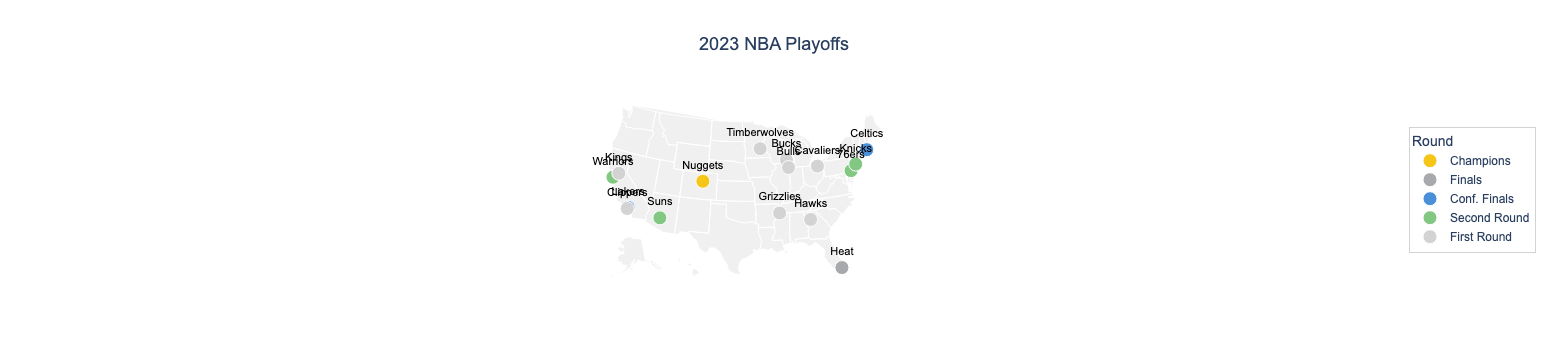

In [81]:
import plotly.express as px
import pandas as pd
#16 teams long and lat 
#Label rounds for each team
#Finish - how far each team got 
all_teams = pd.DataFrame([
    {'Team': 'Nuggets',      'Lat': 39.7,  'Lon': -104.9, 'Round': 'Champions',    'Finish': '1st'},
    {'Team': 'Heat',         'Lat': 25.8,  'Lon': -80.2,  'Round': 'Finals',        'Finish': '2nd'},
    {'Team': 'Lakers',       'Lat': 34.0,  'Lon': -118.2, 'Round': 'Conf. Finals',  'Finish': '3rd'},
    {'Team': 'Celtics',      'Lat': 42.4,  'Lon': -71.1,  'Round': 'Conf. Finals',  'Finish': '3rd'},
    {'Team': '76ers',        'Lat': 39.9,  'Lon': -75.2,  'Round': 'Second Round',  'Finish': '5th'},
    {'Team': 'Knicks',       'Lat': 40.7,  'Lon': -74.0,  'Round': 'Second Round',  'Finish': '5th'},
    {'Team': 'Warriors',     'Lat': 37.8,  'Lon': -122.4, 'Round': 'Second Round',  'Finish': '5th'},
    {'Team': 'Suns',         'Lat': 33.4,  'Lon': -112.1, 'Round': 'Second Round',  'Finish': '5th'},
    {'Team': 'Bucks',        'Lat': 43.0,  'Lon': -87.9,  'Round': 'First Round',   'Finish': '9th'},
    {'Team': 'Bulls',        'Lat': 41.8,  'Lon': -87.6,  'Round': 'First Round',   'Finish': '9th'},
    {'Team': 'Cavaliers',    'Lat': 41.5,  'Lon': -81.7,  'Round': 'First Round',   'Finish': '9th'},
    {'Team': 'Hawks',        'Lat': 33.7,  'Lon': -84.4,  'Round': 'First Round',   'Finish': '9th'},
    {'Team': 'Kings',        'Lat': 38.6,  'Lon': -121.5, 'Round': 'First Round',   'Finish': '9th'},
    {'Team': 'Clippers',     'Lat': 33.8,  'Lon': -118.3, 'Round': 'First Round',   'Finish': '9th'},
    {'Team': 'Grizzlies',    'Lat': 35.1,  'Lon': -90.0,  'Round': 'First Round',   'Finish': '9th'},
    {'Team': 'Timberwolves', 'Lat': 44.9,  'Lon': -93.3,  'Round': 'First Round',   'Finish': '9th'},
])
#Use Hex code for each teams for color map
#sort rounds in order 
round_order = ['Champions', 'Finals', 'Conf. Finals', 'Second Round', 'First Round']
color_map = {
    'Champions':   '#F5C518',
    'Finals':      '#A8A9AD',
    'Conf. Finals':'#4A90D9',
    'Second Round':'#82C882',
    'First Round': '#D3D3D3',
}
#Print map figure 
fig = px.scatter_geo(
    all_teams,
    lat='Lat',
    lon='Lon',
    color='Round',
    text='Team',
    scope='usa',
    title='2023 NBA Playoffs',
    color_discrete_map=color_map,
    category_orders={'Round': round_order},
    hover_data={'Team': True, 'Round': True, 'Lat': False, 'Lon': False}
)
#Dot size and labels 
fig.update_traces(
    marker=dict(size=14, line=dict(width=1, color='white')),
    textposition='top center',
    textfont=dict(size=11, color='black')
)
#Style of the map
fig.update_layout(
    font_family='Arial',
    title_font_size=18,
    title_x=0.5,
    paper_bgcolor='white',
    geo=dict(
        bgcolor='white',
        landcolor='#f0f0f0',
        subunitcolor='white',
        countrycolor='white',
        showlakes=False,
        showland=True,
        showsubunits=True,
    ),
    legend=dict(
        title='Round',
        orientation='v',
        x=1.0,
        y=0.5,
        bgcolor='white',
        bordercolor='lightgray',
        borderwidth=1
    )
)

fig.show()